# Causal Analysis Notebook

This notebook contains functions for tables and visualizations based on the company data CSV.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from econml.dml import LinearDML
from scipy import stats
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

/mnt/e/NEUConference/ClimateRisk/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data

In [2]:
def load_data(csv_path):
    df = pd.read_csv(csv_path)
    df = df.drop(columns=['Unnamed: 0'], errors='ignore')
    return df

df = load_data('/mnt/e/NEUConference/ClimateRisk/output_tfidf/Combined_Company_Data_2022_2024_Final2.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1683, 29)


,Identifier,Company Name,Country of Exchange,GICS Industry Name,year,FV,ESG,SIZE,LEV,lctat,lctlt,chlct,CH,CF,cheat,Inventory,Fixed,Growth,NI,BoardMeetings,Female,CEO,G_score,E_score,GDPgrowth,GDPpercapita,INF,ClimateRiskScore,n_years
0,ABB.NS,ABB India Ltd,India,Electrical Equipment,2022,10.906209,44.221889,9.051739,0.003551,0.466863,0.993496,0.054906,0.311218,2.935031e+08,0.405037,0.158830,0.101999,11.234852,1.239902e+08,7.0,50.0,TRUE,47.506126,38.470741,7.609365,3.370596,5.897142,2.069082,3.0
1,ABB.NS,ABB India Ltd,India,Electrical Equipment,2023,9.331633,40.135368,9.121368,0.004452,0.455783,0.991609,0.074810,0.045611,-2.728669e+08,0.513747,0.149719,0.094118,21.238249,1.500397e+08,4.0,50.0,TRUE,36.294743,38.995411,9.190755,3.403141,2.591949,1.968976,3.0
2,ABB.NS,ABB India Ltd,India,Electrical Equipment,2024,8.386556,47.198509,9.160877,0.004187,0.425617,0.992105,0.055979,0.051681,6.867008e+06,0.486353,0.149049,0.091936,13.449518,2.191142e+08,4.0,50.0,TRUE,42.372799,39.122829,6.484224,3.430827,3.201810,1.980819,3.0
3,ACEL.NS,Action Construction Equipment Ltd,India,Machinery,2022,6.897008,23.456858,8.289389,0.004656,0.414362,0.973121,0.008437,0.009932,1.917916e+06,0.184338,0.271370,0.311208,22.434402,2.105442e+07,4.0,37.5,TRUE,52.267670,6.552428,7.609365,3.370596,5.897142,1.207570,3.0
4,ACEL.NS,Action Construction Equipment Ltd,India,Machinery,2023,5.641235,23.422289,8.415397,0.002057,0.426222,0.984238,0.015599,0.015574,3.206359e+06,0.293260,0.262316,0.278304,32.992226,3.937591e+07,4.0,37.5,TRUE,42.599365,7.553465,9.190755,3.403141,2.591949,1.000000,3.0


## Variable Mapping

In [3]:
def map_variables(df):
    var_map = {
        'Tobins_Q': 'FV',
        'Climate_Risk_TFIDF': 'ClimateRiskScore',
        'ESG': 'ESG',
        'SIZE': 'SIZE',
        'LEV': 'LEV',
        'STDebt_TA': 'lctat',
        'STDebt_TL': 'lctlt',
        'IntExp_Sales': 'chlct',
        'Cash_TA_lag': 'cheat',
        'Inventory_Sales': 'Inventory',
        'Growth': 'Growth',
        'Net_Income_After_Tax': 'NI',
        'GDP_Growth': 'GDPgrowth',
        'Inf': 'INF',
        'Country': 'Country of Exchange',
        'Year': 'year',
        'GICS': 'GICS Industry Name',
        'Company': 'Company Name'
    }
    mapped_df = pd.DataFrame()
    for new_name, old_name in var_map.items():
        if old_name in df.columns:
            mapped_df[new_name] = df[old_name]
    mapped_df = mapped_df.dropna()
    return mapped_df

df_mapped = map_variables(df)
print(f'Mapped dataset shape: {df_mapped.shape}')
df_mapped.head()

Mapped dataset shape: (1683, 18)


,Tobins_Q,Climate_Risk_TFIDF,ESG,SIZE,LEV,STDebt_TA,STDebt_TL,IntExp_Sales,Cash_TA_lag,Inventory_Sales,Growth,Net_Income_After_Tax,GDP_Growth,Inf,Country,Year,GICS,Company
0,10.906209,2.069082,44.221889,9.051739,0.003551,0.466863,0.993496,0.054906,0.405037,0.158830,11.234852,1.239902e+08,7.609365,5.897142,India,2022,Electrical Equipment,ABB India Ltd
1,9.331633,1.968976,40.135368,9.121368,0.004452,0.455783,0.991609,0.074810,0.513747,0.149719,21.238249,1.500397e+08,9.190755,2.591949,India,2023,Electrical Equipment,ABB India Ltd
2,8.386556,1.980819,47.198509,9.160877,0.004187,0.425617,0.992105,0.055979,0.486353,0.149049,13.449518,2.191142e+08,6.484224,3.201810,India,2024,Electrical Equipment,ABB India Ltd
3,6.897008,1.207570,23.456858,8.289389,0.004656,0.414362,0.973121,0.008437,0.184338,0.271370,22.434402,2.105442e+07,7.609365,5.897142,India,2022,Machinery,Action Construction Equipment Ltd
4,5.641235,1.000000,23.422289,8.415397,0.002057,0.426222,0.984238,0.015599,0.293260,0.262316,32.992226,3.937591e+07,9.190755,2.591949,India,2023,Machinery,Action Construction Equipment Ltd


In [4]:
def get_analysis_vars(df):
    y_col = 'Tobins_Q'
    t_col = 'Climate_Risk_TFIDF'
    x_cols = ['SIZE', 'LEV', 'STDebt_TA', 'STDebt_TL', 'IntExp_Sales', 
              'Cash_TA_lag', 'Inventory_Sales', 'Growth', 
              'Net_Income_After_Tax', 'GDP_Growth', 'Inf']
    return y_col, t_col, x_cols

y_col, t_col, x_cols = get_analysis_vars(df_mapped)
print(f'Outcome (Y): {y_col}')
print(f'Treatment (T): {t_col}')
print(f'Confounders (X): {x_cols}')

Outcome (Y): Tobins_Q
Treatment (T): Climate_Risk_TFIDF
Confounders (X): ['SIZE', 'LEV', 'STDebt_TA', 'STDebt_TL', 'IntExp_Sales', 'Cash_TA_lag', 'Inventory_Sales', 'Growth', 'Net_Income_After_Tax', 'GDP_Growth', 'Inf']


## TABLE 1: Descriptive Statistics

In [5]:
def table_descriptive_statistics(df, y_col, t_col, x_cols):
    all_vars = [y_col, t_col] + x_cols
    stats_df = pd.DataFrame()
    for var in all_vars:
        if var in df.columns:
            data = df[var]
            stats_df[var] = {
                'N': len(data),
                'Mean': data.mean(),
                'Std': data.std(),
                'Min': data.min(),
                '25%': data.quantile(0.25),
                'Median': data.quantile(0.5),
                '75%': data.quantile(0.75),
                'Max': data.max()
            }
    stats_df = stats_df.T
    stats_df.index.name = 'Variable'
    return stats_df.round(4)

table1 = table_descriptive_statistics(df_mapped, y_col, t_col, x_cols)
table1

,N,Mean,Std,Min,25%,Median,75%,Max
Variable,,,,,,,,
Tobins_Q,1683.0,2.727600e+00,3.283700e+00,2.230000e-02,6.027000e-01,1.527800e+00,3.594400e+00,2.366810e+01
Climate_Risk_TFIDF,1683.0,1.767200e+00,6.511000e-01,0.000000e+00,1.395000e+00,1.769700e+00,2.165300e+00,3.887900e+00
SIZE,1683.0,8.807900e+00,6.606000e-01,6.799300e+00,8.352500e+00,8.755400e+00,9.189100e+00,1.135830e+01
LEV,1683.0,1.911000e-01,1.689000e-01,0.000000e+00,4.270000e-02,1.615000e-01,3.019000e-01,1.317900e+00
STDebt_TA,1683.0,2.792000e-01,1.730000e-01,0.000000e+00,1.594000e-01,2.508000e-01,3.614000e-01,2.398600e+00
STDebt_TL,1683.0,6.471000e-01,2.297000e-01,0.000000e+00,4.788000e-01,6.813000e-01,8.367000e-01,1.060500e+00
IntExp_Sales,1683.0,3.166000e-01,2.703100e+00,0.000000e+00,2.160000e-02,7.510000e-02,2.047000e-01,1.070877e+02
Cash_TA_lag,1683.0,1.626000e-01,1.515000e-01,2.000000e-04,5.230000e-02,1.176000e-01,2.253000e-01,1.341300e+00
Inventory_Sales,1683.0,1.450000e-01,1.259000e-01,0.000000e+00,3.750000e-02,1.282000e-01,2.172000e-01,7.917000e-01


## TABLE 2: Covariate Balance (Treatment vs Control)

In [6]:
def table_covariate_balance(df, t_col, x_cols, threshold=0.1):
    median_t = df[t_col].median()
    treatment = df[df[t_col] >= median_t]
    control = df[df[t_col] < median_t]
    balance_df = pd.DataFrame()
    for var in x_cols:
        if var in df.columns:
            t_mean = treatment[var].mean()
            c_mean = control[var].mean()
            pooled_std = np.sqrt((treatment[var].std()**2 + control[var].std()**2) / 2)
            smd = (t_mean - c_mean) / pooled_std if pooled_std > 0 else 0
            balanced = 'Yes' if abs(smd) < threshold else 'No'
            balance_df[var] = {
                'Mean (Treatment)': t_mean,
                'Mean (Control)': c_mean,
                'SMD': smd,
                'Balanced': balanced
            }
    balance_df = balance_df.T
    balance_df.index.name = 'Covariate'
    return balance_df.round(4)

table2 = table_covariate_balance(df_mapped, t_col, x_cols)
table2

,Mean (Treatment),Mean (Control),SMD,Balanced
Covariate,,,,
SIZE,9.009551,8.605998,0.641365,No
LEV,0.199496,0.182762,0.099154,Yes
STDebt_TA,0.292957,0.265353,0.160051,No
STDebt_TL,0.641952,0.652318,-0.045124,Yes
IntExp_Sales,0.160389,0.472941,-0.115753,No
Cash_TA_lag,0.150735,0.17448,-0.157204,No
Inventory_Sales,0.142553,0.147403,-0.038518,Yes
Growth,10.973312,10.388439,0.006784,Yes
Net_Income_After_Tax,254085630.109444,67060024.780375,0.260682,No


## TABLE 3: ML Model Performance (Nuisance Functions)

In [7]:
def table_ml_performance(df, y_col, t_col, x_cols, cv_folds=5):
    X = df[x_cols].values
    Y = df[y_col].values
    T = df[t_col].values
    results = []
    
    rf_y = RandomForestRegressor(n_estimators=100, random_state=42)
    y_pred_rf = cross_val_predict(rf_y, X, Y, cv=cv_folds)
    results.append({
        'Model': 'Random Forest (Y)',
        'Target': 'Outcome (Y)',
        'R2': r2_score(Y, y_pred_rf),
        'RMSE': np.sqrt(mean_squared_error(Y, y_pred_rf)),
        'MAE': mean_absolute_error(Y, y_pred_rf)
    })
    
    xgb_y = xgb.XGBRegressor(n_estimators=100, max_depth=3, random_state=42, verbosity=0)
    y_pred_xgb = cross_val_predict(xgb_y, X, Y, cv=cv_folds)
    results.append({
        'Model': 'XGBoost (Y)',
        'Target': 'Outcome (Y)',
        'R2': r2_score(Y, y_pred_xgb),
        'RMSE': np.sqrt(mean_squared_error(Y, y_pred_xgb)),
        'MAE': mean_absolute_error(Y, y_pred_xgb)
    })
    
    rf_t = RandomForestRegressor(n_estimators=100, random_state=42)
    t_pred_rf = cross_val_predict(rf_t, X, T, cv=cv_folds)
    results.append({
        'Model': 'Random Forest (T)',
        'Target': 'Treatment (T)',
        'R2': r2_score(T, t_pred_rf),
        'RMSE': np.sqrt(mean_squared_error(T, t_pred_rf)),
        'MAE': mean_absolute_error(T, t_pred_rf)
    })
    
    xgb_t = xgb.XGBRegressor(n_estimators=100, max_depth=3, random_state=42, verbosity=0)
    t_pred_xgb = cross_val_predict(xgb_t, X, T, cv=cv_folds)
    results.append({
        'Model': 'XGBoost (T)',
        'Target': 'Treatment (T)',
        'R2': r2_score(T, t_pred_xgb),
        'RMSE': np.sqrt(mean_squared_error(T, t_pred_xgb)),
        'MAE': mean_absolute_error(T, t_pred_xgb)
    })
    
    return pd.DataFrame(results).round(4)

table3 = table_ml_performance(df_mapped, y_col, t_col, x_cols)
table3

,Model,Target,R2,RMSE,MAE
0,Random Forest (Y),Outcome (Y),0.2685,2.8075,1.8502
1,XGBoost (Y),Outcome (Y),0.3145,2.7179,1.7793
2,Random Forest (T),Treatment (T),0.0586,0.6316,0.4785
3,XGBoost (T),Treatment (T),-0.0809,0.6767,0.5097


## TABLE 4: Baseline OLS Results

In [8]:
def table_ols_results(df, y_col, t_col, x_cols):
    Y = df[y_col].values
    T = df[t_col].values
    X = df[x_cols].values
    results = []
    
    T_naive = sm.add_constant(T)
    model_naive = sm.OLS(Y, T_naive).fit()
    results.append({
        'Model': 'OLS (Naive)',
        'ATE': model_naive.params[1],
        'Std_Error': model_naive.bse[1],
        'CI_Lower': model_naive.conf_int()[1, 0],
        'CI_Upper': model_naive.conf_int()[1, 1],
        'P_Value': model_naive.pvalues[1]
    })
    
    X_full = np.column_stack([T, X])
    X_full = sm.add_constant(X_full)
    model_controls = sm.OLS(Y, X_full).fit()
    results.append({
        'Model': 'OLS (With Controls)',
        'ATE': model_controls.params[1],
        'Std_Error': model_controls.bse[1],
        'CI_Lower': model_controls.conf_int()[1, 0],
        'CI_Upper': model_controls.conf_int()[1, 1],
        'P_Value': model_controls.pvalues[1]
    })
    
    return pd.DataFrame(results).round(6)

table4 = table_ols_results(df_mapped, y_col, t_col, x_cols)
table4

,Model,ATE,Std_Error,CI_Lower,CI_Upper,P_Value
0,OLS (Naive),0.178264,0.122927,-0.062842,0.419370,0.147200
1,OLS (With Controls),0.276231,0.121755,0.037423,0.515039,0.023411


## DML Estimation Functions

In [9]:
def dml_estimate(df, y_col, t_col, x_cols, model_type='rf', cv_folds=5):
    Y = df[y_col].values
    T = df[t_col].values.reshape(-1, 1)
    X = df[x_cols].values
        
    if model_type == 'rf':
        model_y = RandomForestRegressor(n_estimators=100, random_state=42)
        model_t = RandomForestRegressor(n_estimators=100, random_state=42)
    else:
        model_y = xgb.XGBRegressor(n_estimators=100, max_depth=3, random_state=42, verbosity=0)
        model_t = xgb.XGBRegressor(n_estimators=100, max_depth=3, random_state=42, verbosity=0)
    
    dml = LinearDML(
        model_y=model_y,
        model_t=model_t,
        cv=cv_folds,
        random_state=42
    )
    dml.fit(Y, T, X=X)

    effect = dml.effect(X)
    effect_mean = np.mean(effect)

    inference = dml.effect_inference(X)
    ci_lower, ci_upper = inference.conf_int(alpha=0.05)
    ci_lower = np.mean(ci_lower)
    ci_upper = np.mean(ci_upper)
    se = np.mean(inference.stderr)
    try:
        p_value = np.mean(inference.pvalue())
    except:
        z = effect_mean / se if se > 0 else 0
        p_value = 2 * (1 - stats.norm.cdf(abs(z)))

    return {
        'ATE': effect_mean,
        'Std_Error': se,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'P_Value': p_value,
        'Model': dml,
        'Effects': effect
    }


def causal_forest_estimate(df, y_col, t_col, x_cols, n_trees=100):
    Y = df[y_col].values
    T = df[t_col].values
    X = df[x_cols].values
    
    model_y = RandomForestRegressor(n_estimators=n_trees, random_state=42)
    model_t = RandomForestRegressor(n_estimators=n_trees, random_state=42)
    
    model_y.fit(X, Y)
    model_t.fit(X, T)
    
    y_pred = model_y.predict(X)
    t_pred = model_t.predict(X)
    
    y_resid = Y - y_pred
    t_resid = T - t_pred
    
    theta = np.sum(y_resid * t_resid) / np.sum(t_resid ** 2)
    
    residuals = y_resid - theta * t_resid
    sigma2 = np.sum(residuals ** 2) / len(residuals)
    se = np.sqrt(sigma2 / np.sum(t_resid ** 2))
    
    ci_lower = theta - 1.96 * se
    ci_upper = theta + 1.96 * se
    z_score = theta / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
    
    return {
        'ATE': theta,
        'Std_Error': se,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'P_Value': p_value
    }

## TABLE 5: Main Causal Estimates (DML Results)

In [10]:
def table_causal_estimates(df, y_col, t_col, x_cols):
    results = []
    
    dml_rf = dml_estimate(df, y_col, t_col, x_cols, model_type='rf')
    results.append({
        'Algorithm': 'DML - Random Forest',
        'ATE': dml_rf['ATE'],
        'Std_Error': dml_rf['Std_Error'],
        'CI_Lower': dml_rf['CI_Lower'],
        'CI_Upper': dml_rf['CI_Upper'],
        'P_Value': dml_rf['P_Value']
    })
    
    dml_xgb = dml_estimate(df, y_col, t_col, x_cols, model_type='xgb')
    results.append({
        'Algorithm': 'DML - XGBoost',
        'ATE': dml_xgb['ATE'],
        'Std_Error': dml_xgb['Std_Error'],
        'CI_Lower': dml_xgb['CI_Lower'],
        'CI_Upper': dml_xgb['CI_Upper'],
        'P_Value': dml_xgb['P_Value']
    })
    
    cf = causal_forest_estimate(df, y_col, t_col, x_cols)
    results.append({
        'Algorithm': 'Causal Forest',
        'ATE': cf['ATE'],
        'Std_Error': cf['Std_Error'],
        'CI_Lower': cf['CI_Lower'],
        'CI_Upper': cf['CI_Upper'],
        'P_Value': cf['P_Value']
    })
    
    return pd.DataFrame(results).round(6)

table5 = table_causal_estimates(df_mapped, y_col, t_col, x_cols)
table5

,Algorithm,ATE,Std_Error,CI_Lower,CI_Upper,P_Value
0,DML - Random Forest,-0.102566,0.053033,-0.206508,0.001377,0.071872
1,DML - XGBoost,-0.083207,0.050284,-0.181762,0.015348,0.048042
2,Causal Forest,-0.083673,0.096874,-0.273546,0.106201,0.387739


## TABLE 6: Comparison Across Methods

In [11]:
def table_method_comparison(df, y_col, t_col, x_cols):
    results = []
    
    Y = df[y_col].values
    T = df[t_col].values
    X = df[x_cols].values
    
    T_naive = sm.add_constant(T)
    model_naive = sm.OLS(Y, T_naive).fit()
    results.append({
        'Method': 'OLS (Naive)',
        'ATE': model_naive.params[1],
        'Std_Error': model_naive.bse[1],
        'CI': f"[{model_naive.conf_int()[1, 0]:.4f}, {model_naive.conf_int()[1, 1]:.4f}]",
        'Interpretation': 'Likely upward biased'
    })
    
    X_full = np.column_stack([T, X])
    X_full = sm.add_constant(X_full)
    model_controls = sm.OLS(Y, X_full).fit()
    results.append({
        'Method': 'OLS (With Controls)',
        'ATE': model_controls.params[1],
        'Std_Error': model_controls.bse[1],
        'CI': f"[{model_controls.conf_int()[1, 0]:.4f}, {model_controls.conf_int()[1, 1]:.4f}]",
        'Interpretation': 'Reduced bias'
    })
    
    dml_rf = dml_estimate(df, y_col, t_col, x_cols, model_type='rf')
    results.append({
        'Method': 'DML - Random Forest',
        'ATE': dml_rf['ATE'],
        'Std_Error': dml_rf['Std_Error'],
        'CI': f"[{dml_rf['CI_Lower']:.4f}, {dml_rf['CI_Upper']:.4f}]",
        'Interpretation': 'Nonlinear adjustment'
    })
    
    dml_xgb = dml_estimate(df, y_col, t_col, x_cols, model_type='xgb')
    results.append({
        'Method': 'DML - XGBoost',
        'ATE': dml_xgb['ATE'],
        'Std_Error': dml_xgb['Std_Error'],
        'CI': f"[{dml_xgb['CI_Lower']:.4f}, {dml_xgb['CI_Upper']:.4f}]",
        'Interpretation': 'Preferred model'
    })
    
    return pd.DataFrame(results).round(6)

table6 = table_method_comparison(df_mapped, y_col, t_col, x_cols)
table6

,Method,ATE,Std_Error,CI,Interpretation
0,OLS (Naive),0.178264,0.122927,"[-0.0628, 0.4194]",Likely upward biased
1,OLS (With Controls),0.276231,0.121755,"[0.0374, 0.5150]",Reduced bias
2,DML - Random Forest,-0.102566,0.053033,"[-0.2065, 0.0014]",Nonlinear adjustment
3,DML - XGBoost,-0.083207,0.050284,"[-0.1818, 0.0153]",Preferred model


## TABLE 7: Heterogeneous Treatment Effects (CATE)

In [12]:
def table_cate_by_subgroup(df, y_col, t_col, x_cols, subgroup_col='ESG'):
    if subgroup_col not in df.columns:
        return pd.DataFrame({'Error': ['Subgroup column not found']})
    
    df = df.copy()
    df['subgroup_bin'] = pd.qcut(df[subgroup_col], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop')
    
    results = []
    for subgroup in df['subgroup_bin'].unique():
        subgroup_df = df[df['subgroup_bin'] == subgroup]
        if len(subgroup_df) < 10:
            continue
        
        dml_result = dml_estimate(subgroup_df, y_col, t_col, x_cols, model_type='rf')
        results.append({
            'Subgroup': f'{subgroup_col} - {subgroup}',
            'N': len(subgroup_df),
            'CATE': dml_result['ATE'],
            'Std_Error': dml_result['Std_Error'],
            'CI_Lower': dml_result['CI_Lower'],
            'CI_Upper': dml_result['CI_Upper']
        })
    
    return pd.DataFrame(results).round(6)

table7 = table_cate_by_subgroup(df_mapped, y_col, t_col, x_cols, subgroup_col='ESG')
table7

,Subgroup,N,CATE,Std_Error,CI_Lower,CI_Upper
0,ESG - Medium,561,0.037320,0.005133,0.027260,0.047380
1,ESG - Low,561,0.030818,0.033871,-0.035567,0.097203
2,ESG - High,561,-0.153195,0.151035,-0.449218,0.142829


## TABLE 8: Robustness and Placebo Tests

In [13]:
def table_robustness_tests(df, y_col, t_col, x_cols):
    results = []
    
    baseline = dml_estimate(df, y_col, t_col, x_cols, model_type='xgb')
    results.append({
        'Specification': 'Baseline (DML-XGBoost)',
        'ATE': baseline['ATE'],
        'Std_Error': baseline['Std_Error'],
        'P_Value': baseline['P_Value'],
        'Conclusion': 'Significant' if baseline['P_Value'] < 0.05 else 'Not significant'
    })
    
    df_placebo = df.copy()
    np.random.seed(42)
    df_placebo[t_col] = np.random.permutation(df_placebo[t_col].values)
    placebo = dml_estimate(df_placebo, y_col, t_col, x_cols, model_type='xgb')
    results.append({
        'Specification': 'Placebo Test (Randomized T)',
        'ATE': placebo['ATE'],
        'Std_Error': placebo['Std_Error'],
        'P_Value': placebo['P_Value'],
        'Conclusion': 'Not significant (expected)'
    })
    
    q75 = df[y_col].quantile(0.75)
    q25 = df[y_col].quantile(0.25)
    iqr = q75 - q25
    df_no_outliers = df[(df[y_col] >= q25 - 1.5*iqr) & (df[y_col] <= q75 + 1.5*iqr)]
    no_outliers = dml_estimate(df_no_outliers, y_col, t_col, x_cols, model_type='xgb')
    results.append({
        'Specification': 'Remove Outliers',
        'ATE': no_outliers['ATE'],
        'Std_Error': no_outliers['Std_Error'],
        'P_Value': no_outliers['P_Value'],
        'Conclusion': 'Robust' if abs(no_outliers['ATE'] - baseline['ATE']) < 0.5 else 'Different'
    })
    
    rf_result = dml_estimate(df, y_col, t_col, x_cols, model_type='rf')
    results.append({
        'Specification': 'Alternative Model (RF)',
        'ATE': rf_result['ATE'],
        'Std_Error': rf_result['Std_Error'],
        'P_Value': rf_result['P_Value'],
        'Conclusion': 'Consistent' if abs(rf_result['ATE'] - baseline['ATE']) < 0.5 else 'Different'
    })
    
    return pd.DataFrame(results).round(6)

table8 = table_robustness_tests(df_mapped, y_col, t_col, x_cols)
table8

,Specification,ATE,Std_Error,P_Value,Conclusion
0,Baseline (DML-XGBoost),-0.083207,0.050284,0.048042,Significant
1,Placebo Test (Randomized T),-0.067674,0.041881,0.080359,Not significant (expected)
2,Remove Outliers,0.155368,0.020586,0.037284,Robust
3,Alternative Model (RF),-0.102566,0.053033,0.071872,Consistent


## FIGURE 1: Overlap / Common Support Plot

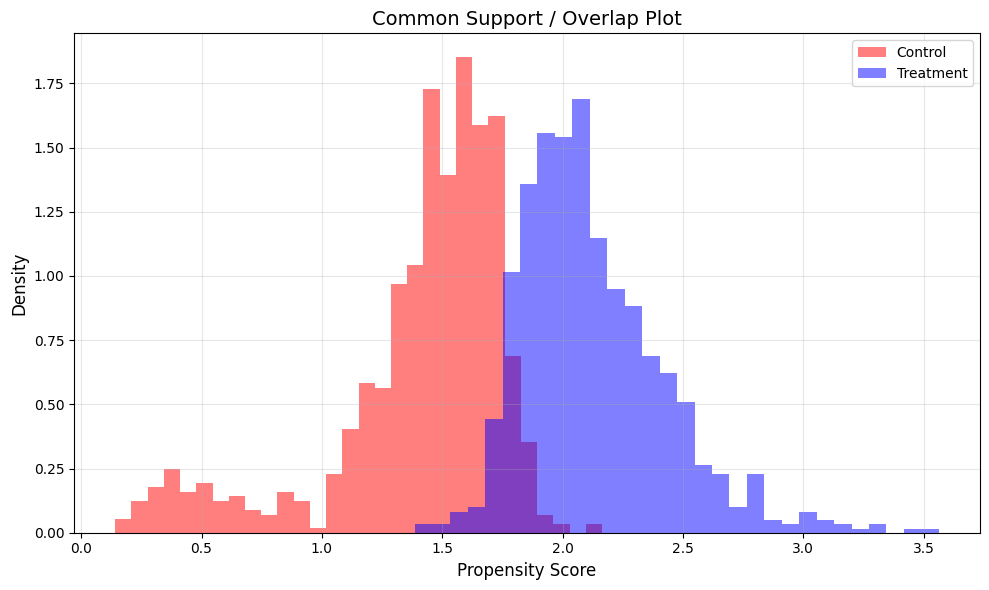

In [14]:
def plot_overlap_common_support(df, t_col, x_cols, save_path=None):
    X = df[x_cols].values
    T = df[t_col].values
    
    model_t = RandomForestRegressor(n_estimators=100, random_state=42)
    model_t.fit(X, T)
    propensity_scores = model_t.predict(X)
    
    median_t = df[t_col].median()
    treated = propensity_scores[T >= median_t]
    control = propensity_scores[T < median_t]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.hist(control, bins=30, alpha=0.5, label='Control', color='red', density=True)
    ax.hist(treated, bins=30, alpha=0.5, label='Treatment', color='blue', density=True)
    
    ax.set_xlabel('Propensity Score', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title('Common Support / Overlap Plot', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return propensity_scores

ps_scores = plot_overlap_common_support(df_mapped, t_col, x_cols)

## FIGURE 2: SHAP Feature Importance

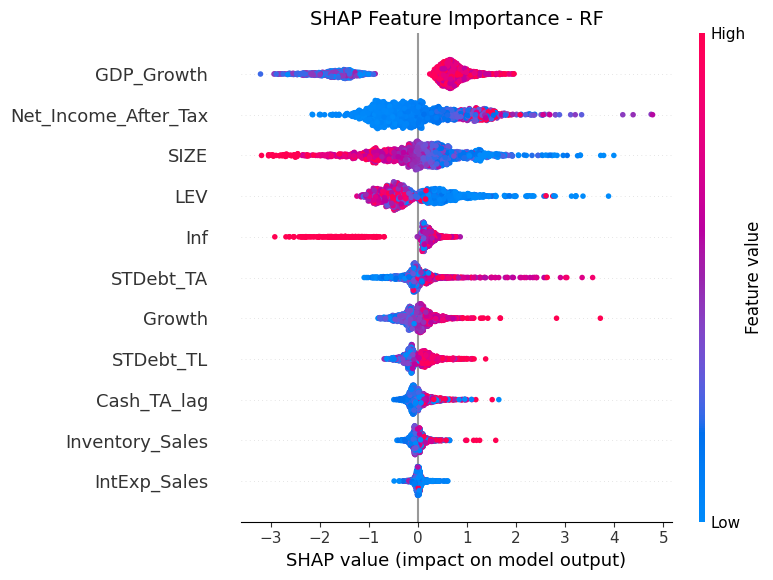

In [15]:
import shap
def plot_shap_feature_importance(df, y_col, x_cols, model_type='rf', save_path=None):
    X = df[x_cols].values
    Y = df[y_col].values
    
    if model_type == 'rf':
        model = RandomForestRegressor(n_estimators=100, random_state=42)
    else:
        model = xgb.XGBRegressor(n_estimators=100, max_depth=3, random_state=42, verbosity=0)
    
    model.fit(X, Y)
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X, feature_names=x_cols, show=False)
    plt.title(f'SHAP Feature Importance - {model_type.upper()}', fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return shap_values

shap_vals_rf = plot_shap_feature_importance(df_mapped, y_col, x_cols, model_type='rf')

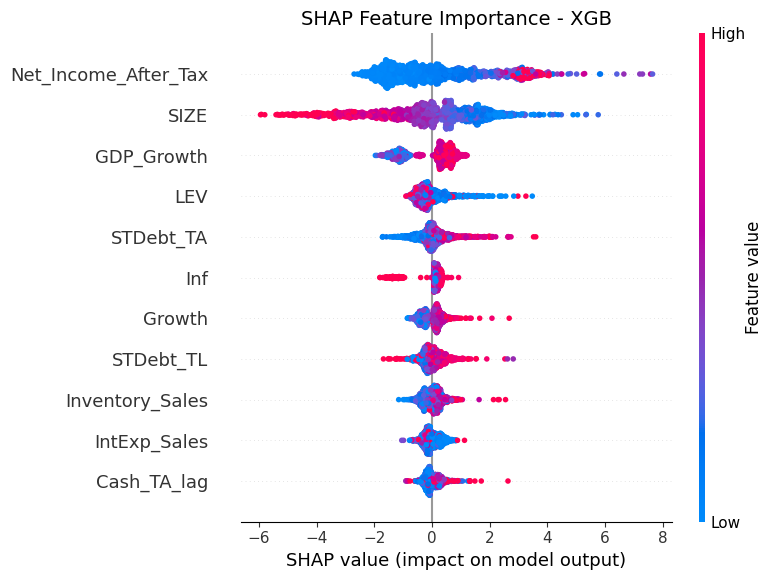

In [16]:
shap_vals_xgb = plot_shap_feature_importance(df_mapped, y_col, x_cols, model_type='xgb')

## FIGURE 3: Distribution of Individual Treatment Effects (CATE Plot)

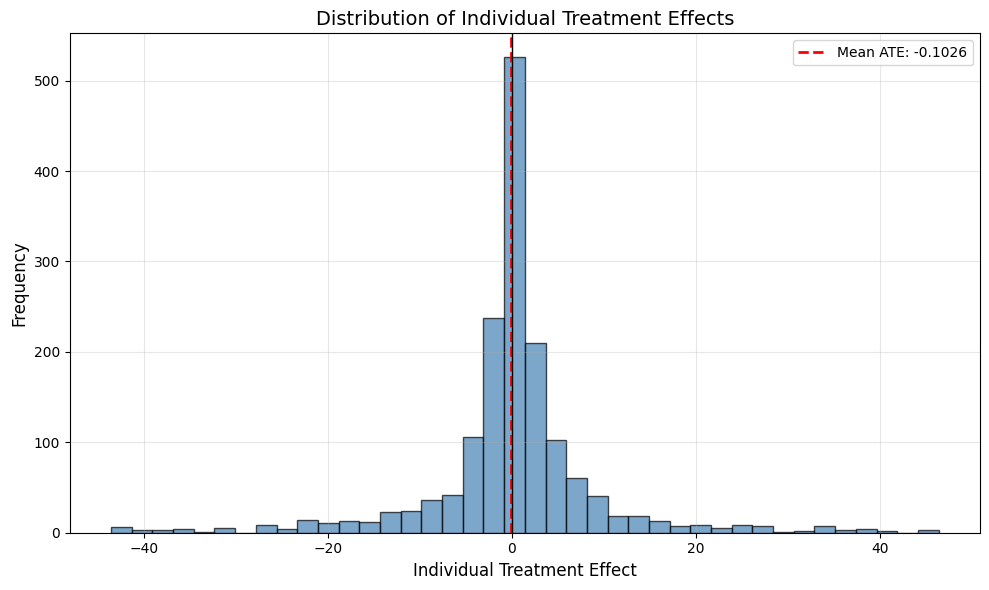

In [17]:
def plot_cate_distribution(df, y_col, t_col, x_cols, save_path=None):
    X = df[x_cols].values
    Y = df[y_col].values
    T = df[t_col].values
    
    dml_result = dml_estimate(df, y_col, t_col, x_cols, model_type='rf')
    ate_mean = dml_result['ATE']
    
    model_y = RandomForestRegressor(n_estimators=100, random_state=42)
    model_t = RandomForestRegressor(n_estimators=100, random_state=42)
    
    model_y.fit(X, Y)
    model_t.fit(X, T)
    
    y_pred = model_y.predict(X)
    t_pred = model_t.predict(X)
    
    y_resid = Y - y_pred
    t_resid = T - t_pred
    
    individual_effects = y_resid / (t_resid + 1e-10)
    individual_effects = individual_effects[np.abs(individual_effects) < np.percentile(np.abs(individual_effects), 95)]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.hist(individual_effects, bins=40, alpha=0.7, color='steelblue', edgecolor='black')
    ax.axvline(ate_mean, color='red', linestyle='--', linewidth=2, label=f'Mean ATE: {ate_mean:.4f}')
    ax.axvline(0, color='black', linestyle='-', linewidth=1)
    
    ax.set_xlabel('Individual Treatment Effect', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Distribution of Individual Treatment Effects', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return individual_effects

cate_dist = plot_cate_distribution(df_mapped, y_col, t_col, x_cols)

## FIGURE 4: Feature Importance (RF/XGBoost)

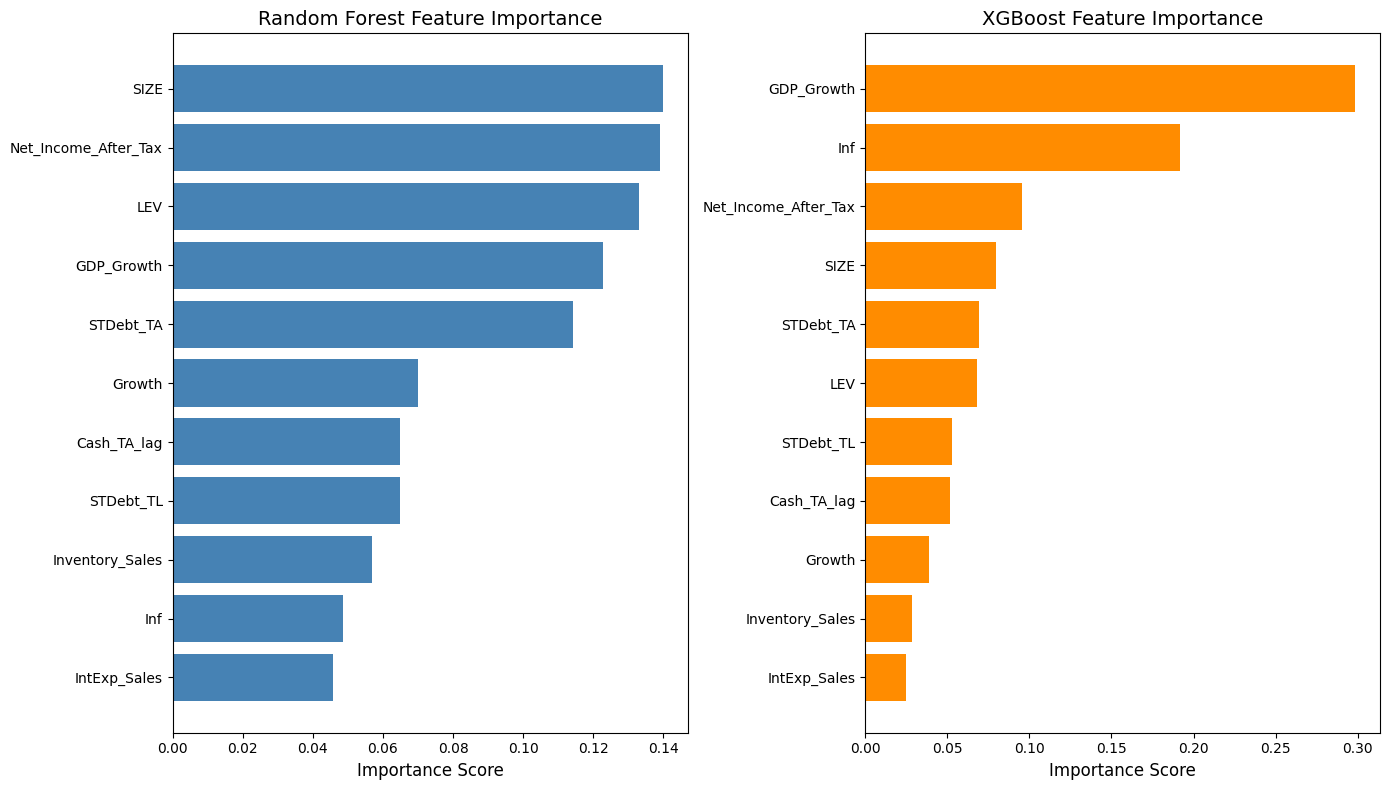

In [18]:
def plot_feature_importance(df, y_col, x_cols, save_path=None):
    X = df[x_cols].values
    Y = df[y_col].values
    
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X, Y)
    rf_importance = pd.DataFrame({'Feature': x_cols, 'Importance': rf.feature_importances_})
    rf_importance = rf_importance.sort_values('Importance', ascending=True)
    
    xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=3, random_state=42, verbosity=0)
    xgb_model.fit(X, Y)
    xgb_importance = pd.DataFrame({'Feature': x_cols, 'Importance': xgb_model.feature_importances_})
    xgb_importance = xgb_importance.sort_values('Importance', ascending=True)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    
    axes[0].barh(rf_importance['Feature'], rf_importance['Importance'], color='steelblue')
    axes[0].set_xlabel('Importance Score', fontsize=12)
    axes[0].set_title('Random Forest Feature Importance', fontsize=14)
    
    axes[1].barh(xgb_importance['Feature'], xgb_importance['Importance'], color='darkorange')
    axes[1].set_xlabel('Importance Score', fontsize=12)
    axes[1].set_title('XGBoost Feature Importance', fontsize=14)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_feature_importance(df_mapped, y_col, x_cols)

## FIGURE 5: Model Comparison Plot (OLS vs RF vs XGBoost ATE)

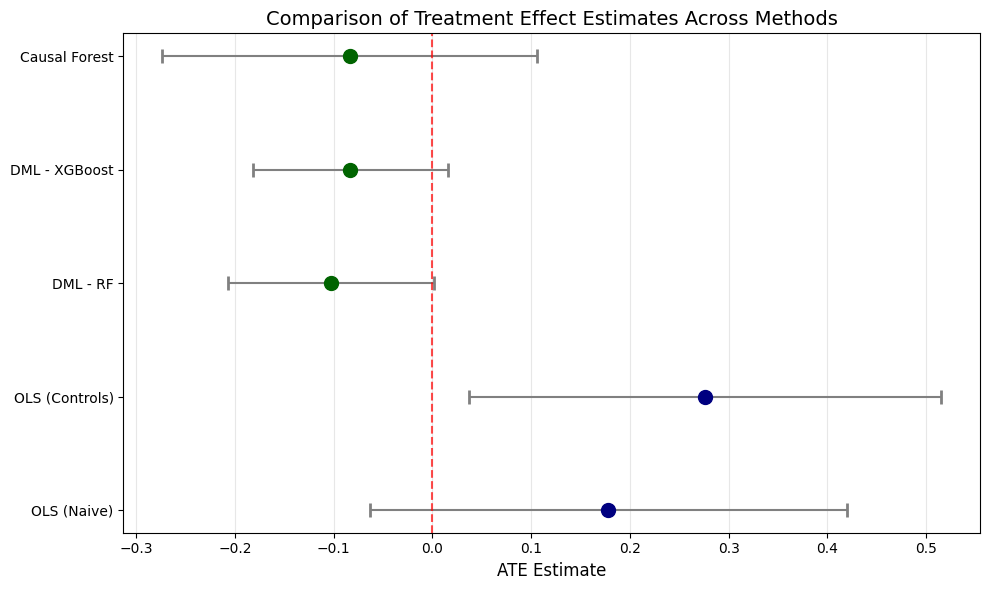

In [19]:
def plot_model_comparison(df, y_col, t_col, x_cols, save_path=None):
    Y = df[y_col].values
    T = df[t_col].values
    X = df[x_cols].values
    
    methods = []
    ates = []
    ci_lowers = []
    ci_uppers = []
    colors = []
    
    T_naive = sm.add_constant(T)
    model_naive = sm.OLS(Y, T_naive).fit()
    methods.append('OLS (Naive)')
    ates.append(model_naive.params[1])
    ci_lowers.append(model_naive.conf_int()[1, 0])
    ci_uppers.append(model_naive.conf_int()[1, 1])
    colors.append('navy')
    
    X_full = np.column_stack([T, X])
    X_full = sm.add_constant(X_full)
    model_controls = sm.OLS(Y, X_full).fit()
    methods.append('OLS (Controls)')
    ates.append(model_controls.params[1])
    ci_lowers.append(model_controls.conf_int()[1, 0])
    ci_uppers.append(model_controls.conf_int()[1, 1])
    colors.append('navy')
    
    dml_rf = dml_estimate(df, y_col, t_col, x_cols, model_type='rf')
    methods.append('DML - RF')
    ates.append(dml_rf['ATE'])
    ci_lowers.append(dml_rf['CI_Lower'])
    ci_uppers.append(dml_rf['CI_Upper'])
    colors.append('darkgreen')
    
    dml_xgb = dml_estimate(df, y_col, t_col, x_cols, model_type='xgb')
    methods.append('DML - XGBoost')
    ates.append(dml_xgb['ATE'])
    ci_lowers.append(dml_xgb['CI_Lower'])
    ci_uppers.append(dml_xgb['CI_Upper'])
    colors.append('darkgreen')
    
    cf = causal_forest_estimate(df, y_col, t_col, x_cols)
    methods.append('Causal Forest')
    ates.append(cf['ATE'])
    ci_lowers.append(cf['CI_Lower'])
    ci_uppers.append(cf['CI_Upper'])
    colors.append('darkgreen')
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    y_pos = np.arange(len(methods))
    errors = np.array([np.array(ates) - np.array(ci_lowers), np.array(ci_uppers) - np.array(ates)])
    
    ax.errorbar(ates, y_pos, xerr=errors, fmt='o', capsize=5, capthick=2, 
                color='black', ecolor='gray', markersize=8)
    
    for i, (method, ate, color) in enumerate(zip(methods, ates, colors)):
        ax.scatter(ate, i, color=color, s=100, zorder=5)
    
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(methods)
    ax.set_xlabel('ATE Estimate', fontsize=12)
    ax.set_title('Comparison of Treatment Effect Estimates Across Methods', fontsize=14)
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_model_comparison(df_mapped, y_col, t_col, x_cols)

## FIGURE 6: Balance Plot (Standardized Mean Differences)

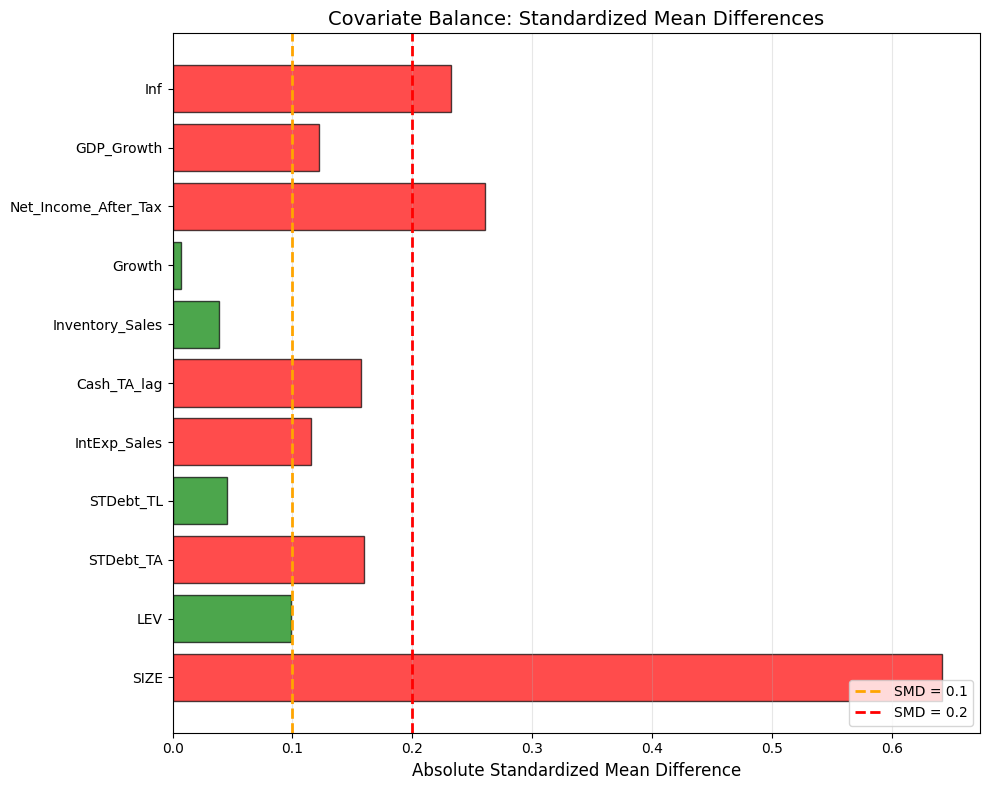

In [20]:
def plot_balance_smd(df, t_col, x_cols, save_path=None):
    median_t = df[t_col].median()
    treatment = df[df[t_col] >= median_t]
    control = df[df[t_col] < median_t]
    
    smd_values = []
    var_names = []
    
    for var in x_cols:
        if var in df.columns:
            t_mean = treatment[var].mean()
            c_mean = control[var].mean()
            pooled_std = np.sqrt((treatment[var].std()**2 + control[var].std()**2) / 2)
            smd = (t_mean - c_mean) / pooled_std if pooled_std > 0 else 0
            smd_values.append(abs(smd))
            var_names.append(var)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = ['green' if s < 0.1 else 'red' for s in smd_values]
    
    y_pos = np.arange(len(var_names))
    ax.barh(y_pos, smd_values, color=colors, edgecolor='black', alpha=0.7)
    
    ax.axvline(0.1, color='orange', linestyle='--', linewidth=2, label='SMD = 0.1')
    ax.axvline(0.2, color='red', linestyle='--', linewidth=2, label='SMD = 0.2')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(var_names)
    ax.set_xlabel('Absolute Standardized Mean Difference', fontsize=12)
    ax.set_title('Covariate Balance: Standardized Mean Differences', fontsize=14)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_balance_smd(df_mapped, t_col, x_cols)

## FIGURE 7: Partial Dependence Plot (PDP)

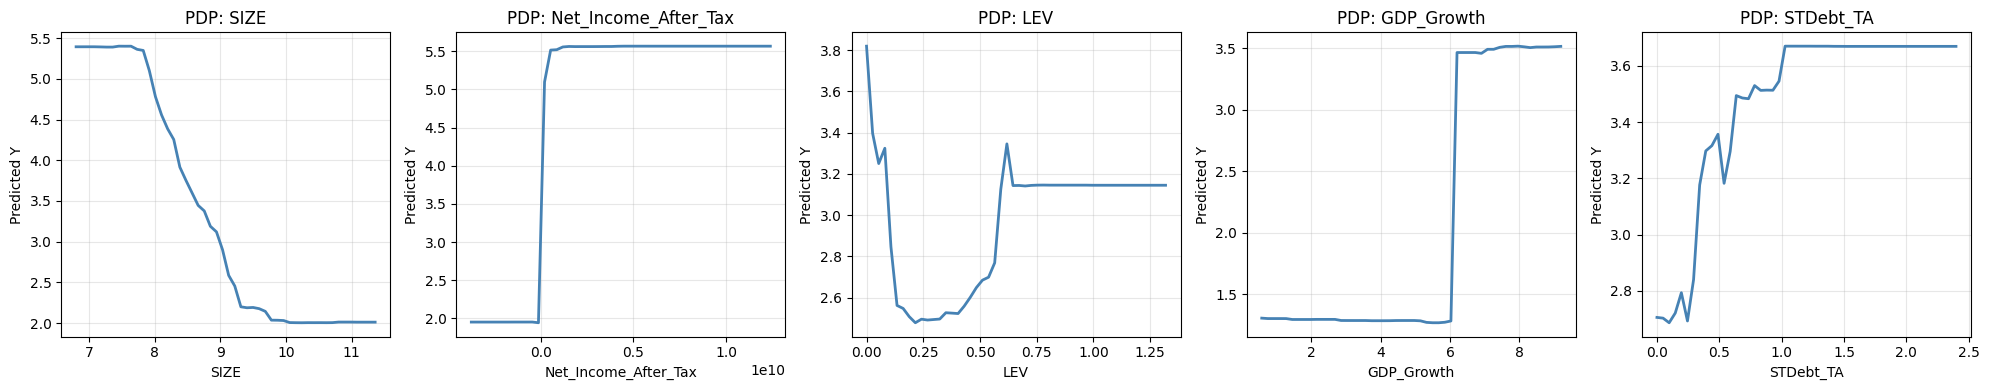

In [21]:
def plot_partial_dependence(df, y_col, x_cols, top_n=5, save_path=None):
    X = df[x_cols].values
    Y = df[y_col].values
    
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X, Y)
    
    importance_df = pd.DataFrame({'Feature': x_cols, 'Importance': rf.feature_importances_})
    importance_df = importance_df.sort_values('Importance', ascending=False)
    top_features = importance_df['Feature'].head(top_n).tolist()
    top_indices = [x_cols.index(f) for f in top_features]
    
    fig, axes = plt.subplots(1, top_n, figsize=(4*top_n, 4))
    if top_n == 1:
        axes = [axes]
    
    for i, (idx, feat) in enumerate(zip(top_indices, top_features)):
        feature_values = np.linspace(X[:, idx].min(), X[:, idx].max(), 50)
        pdp_values = []
        
        for val in feature_values:
            X_temp = X.copy()
            X_temp[:, idx] = val
            pdp_values.append(np.mean(rf.predict(X_temp)))
        
        axes[i].plot(feature_values, pdp_values, color='steelblue', linewidth=2)
        axes[i].set_xlabel(feat, fontsize=10)
        axes[i].set_ylabel('Predicted Y', fontsize=10)
        axes[i].set_title(f'PDP: {feat}', fontsize=12)
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_partial_dependence(df_mapped, y_col, x_cols, top_n=5)

## Additional Utility Functions

In [22]:
def calculate_propensity_scores(df, t_col, x_cols):
    X = df[x_cols].values
    T = df[t_col].values
    
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, T)
    ps = model.predict(X)
    
    return ps

def calculate_individual_cate(df, y_col, t_col, x_cols):
    X = df[x_cols].values
    Y = df[y_col].values
    T = df[t_col].values
    
    model_y = RandomForestRegressor(n_estimators=100, random_state=42)
    model_t = RandomForestRegressor(n_estimators=100, random_state=42)
    
    model_y.fit(X, Y)
    model_t.fit(X, T)
    
    y_pred = model_y.predict(X)
    t_pred = model_t.predict(X)
    
    y_resid = Y - y_pred
    t_resid = T - t_pred
    
    individual_cate = y_resid / (t_resid + 1e-10)
    
    return individual_cate

def export_tables_to_csv(tables_dict, output_dir='./'):
    for name, table in tables_dict.items():
        path = f"{output_dir}{name}.csv"
        table.to_csv(path)
        print(f'Saved: {path}')

## Save All Tables

In [23]:
tables = {
    'table1_descriptive_stats': table1,
    'table2_covariate_balance': table2,
    'table3_ml_performance': table3,
    'table4_ols_results': table4,
    'table5_causal_estimates': table5,
    'table6_method_comparison': table6,
    'table7_cate_subgroups': table7,
    'table8_robustness': table8
}

export_tables_to_csv(tables, output_dir='./output_csv')

Saved: ./output_csvtable1_descriptive_stats.csv
Saved: ./output_csvtable2_covariate_balance.csv
Saved: ./output_csvtable3_ml_performance.csv
Saved: ./output_csvtable4_ols_results.csv
Saved: ./output_csvtable5_causal_estimates.csv
Saved: ./output_csvtable6_method_comparison.csv
Saved: ./output_csvtable7_cate_subgroups.csv
Saved: ./output_csvtable8_robustness.csv


## CATE by ESG Quantiles Analysis

In [24]:
def calculate_cate_by_esg(df, y_col, t_col, x_cols, n_quantiles=10):
    df = df.copy()
    df['ESG_bin'] = pd.qcut(df['ESG'], q=n_quantiles, labels=False, duplicates='drop')
    
    results = []
    for q in df['ESG_bin'].unique():
        subset = df[df['ESG_bin'] == q]
        if len(subset) >= 5:
            dml_res = dml_estimate(subset, y_col, t_col, x_cols, model_type='rf')
            results.append({
                'ESG_Quantile': q,
                'N': len(subset),
                'CATE': dml_res['ATE'],
                'SE': dml_res['Std_Error'],
                'CI_Lower': dml_res['CI_Lower'],
                'CI_Upper': dml_res['CI_Upper'],
                'ESG_Mean': subset['ESG'].mean()
            })
    
    return pd.DataFrame(results).sort_values('ESG_Quantile')

cate_by_esg = calculate_cate_by_esg(df_mapped, y_col, t_col, x_cols)
cate_by_esg

,ESG_Quantile,N,CATE,SE,CI_Lower,CI_Upper,ESG_Mean
2,0,169,-0.019501,0.454452,-0.910211,0.871208,17.896166
7,1,168,0.433542,0.233518,-0.024145,0.891230,26.809332
3,2,168,0.228379,0.008688,0.211349,0.245408,31.995937
8,3,168,0.153216,0.250581,-0.337914,0.644347,37.105693
0,4,169,-0.031071,0.457972,-0.928679,0.866538,42.274696
1,5,168,0.675399,0.520844,-0.345436,1.696235,47.092838
4,6,168,0.215524,0.176336,-0.130088,0.561135,52.234433
6,7,168,-0.701302,0.509284,-1.699480,0.296877,57.778363
9,8,168,-0.169655,0.267291,-0.693537,0.354226,64.226092
5,9,169,-0.140462,0.121280,-0.378166,0.097242,75.898172


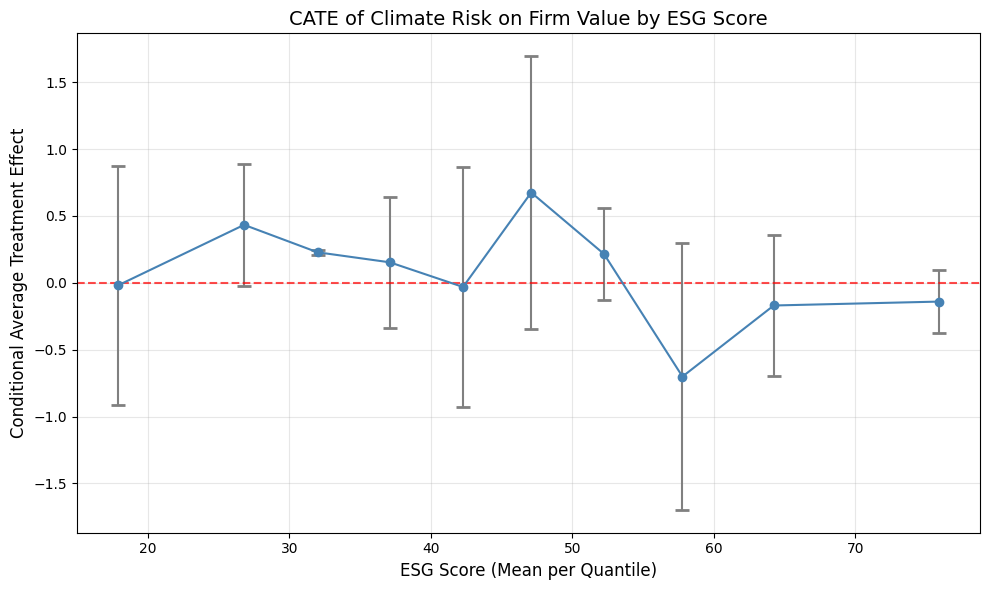

In [25]:
def plot_cate_by_esg_quantiles(cate_df, save_path=None):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.errorbar(cate_df['ESG_Mean'], cate_df['CATE'], 
                yerr=[cate_df['CATE'] - cate_df['CI_Lower'], cate_df['CI_Upper'] - cate_df['CATE']],
                fmt='o-', capsize=5, capthick=2, color='steelblue', ecolor='gray')
    
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.set_xlabel('ESG Score (Mean per Quantile)', fontsize=12)
    ax.set_ylabel('Conditional Average Treatment Effect', fontsize=12)
    ax.set_title('CATE of Climate Risk on Firm Value by ESG Score', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_cate_by_esg_quantiles(cate_by_esg)

## Distribution Plots for Key Variables

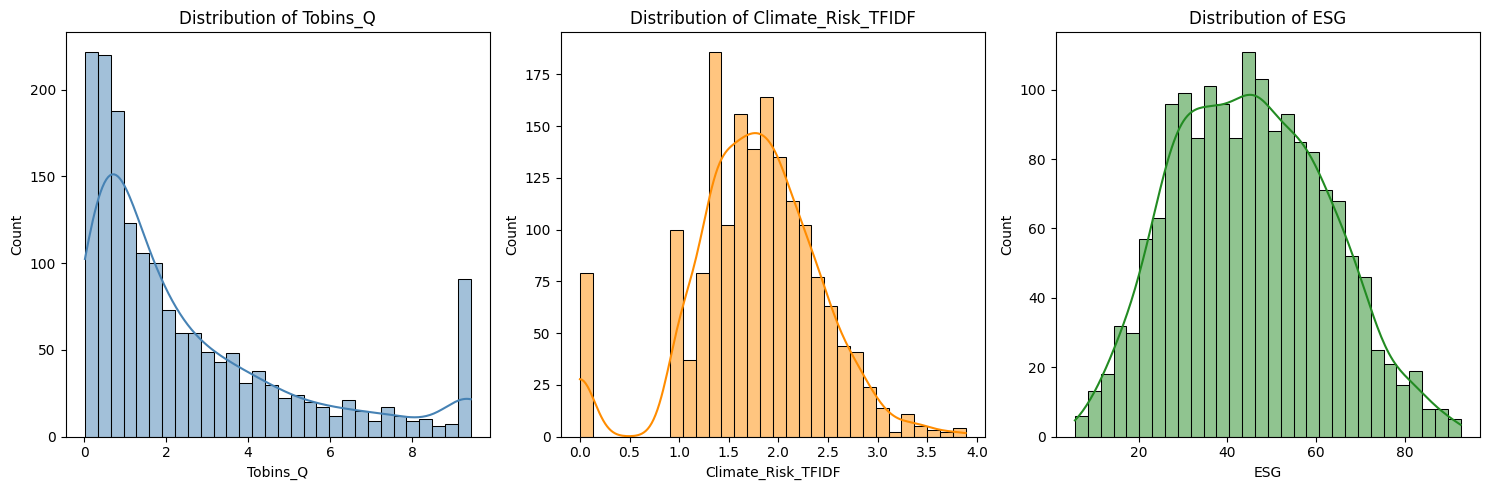

In [26]:
def plot_key_distributions(df, y_col, t_col, save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    y_data = df[y_col].clip(upper=df[y_col].quantile(0.95))
    sns.histplot(y_data, kde=True, ax=axes[0], color='steelblue', bins=30)
    axes[0].set_title(f"Distribution of {y_col}", fontsize=12)
    axes[0].set_xlabel(y_col)
    
    sns.histplot(df[t_col], kde=True, ax=axes[1], color='darkorange', bins=30)
    axes[1].set_title(f"Distribution of {t_col}", fontsize=12)
    axes[1].set_xlabel(t_col)
    
    if 'ESG' in df.columns:
        sns.histplot(df['ESG'], kde=True, ax=axes[2], color='forestgreen', bins=30)
        axes[2].set_title('Distribution of ESG', fontsize=12)
        axes[2].set_xlabel('ESG')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_key_distributions(df_mapped, y_col, t_col)

## Correlation Heatmap

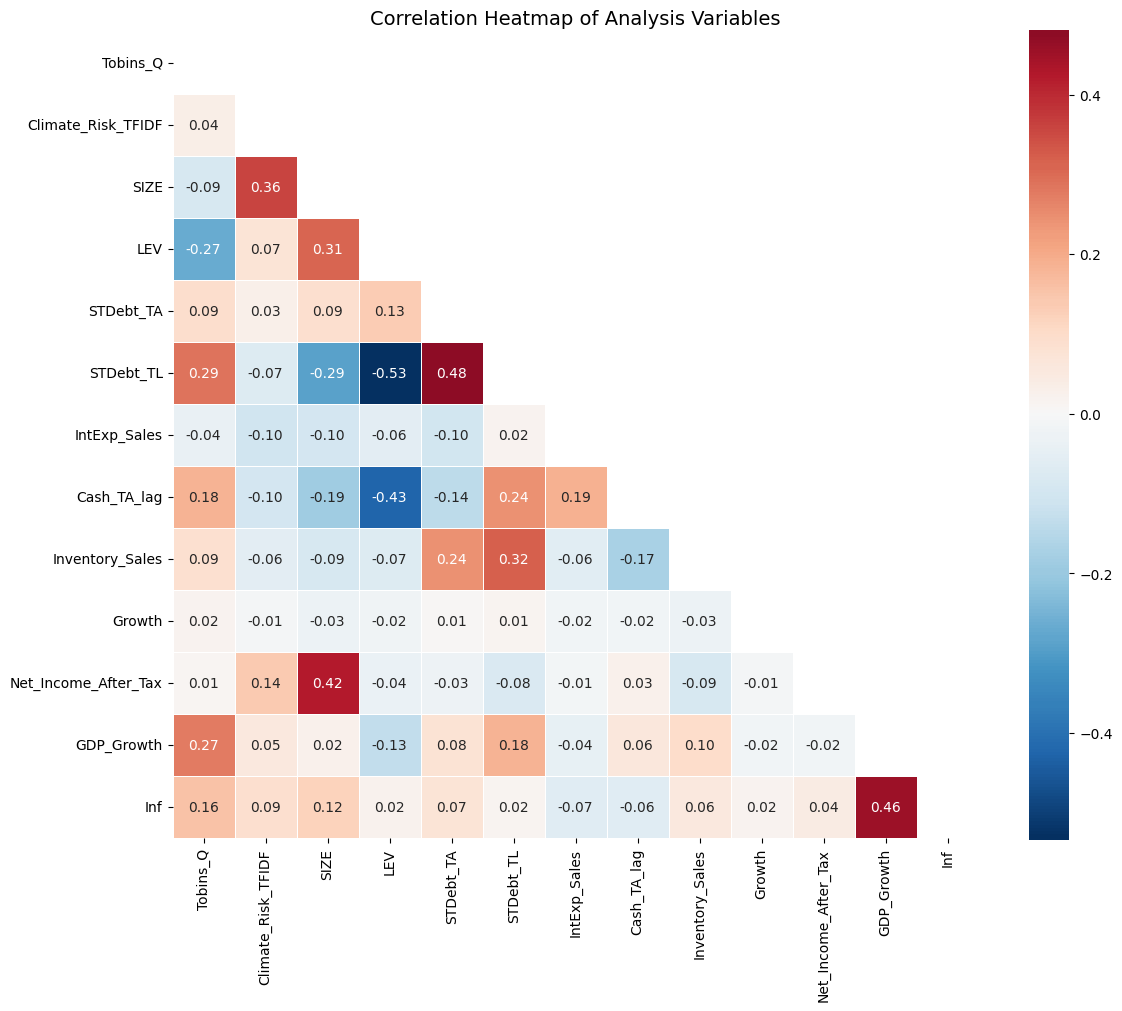

In [27]:
def plot_correlation_heatmap(df, y_col, t_col, x_cols, save_path=None):
    all_cols = [y_col, t_col] + x_cols
    corr_matrix = df[all_cols].corr()
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
                cmap='RdBu_r', center=0, ax=ax, 
                square=True, linewidths=0.5)
    
    ax.set_title('Correlation Heatmap of Analysis Variables', fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_correlation_heatmap(df_mapped, y_col, t_col, x_cols)